In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.16.2
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.16.2
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


<h1>data preprocessing along with increasing the size of val set

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1   # 10% for validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.


<h1>Model Building — DenseNet121

In [6]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load DenseNet121 with ImageNet weights, exclude top layers
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

2025-09-08 20:30:18.666194: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-09-08 20:30:18.666249: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-09-08 20:30:18.666260: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-09-08 20:30:18.666307: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-08 20:30:18.666324: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 15s 1us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [7]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_densenet_model.h5", save_best_only=True)
]

<h1>training the model

In [8]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=15,
    callbacks=callbacks
)

/Users/adityakumar/Desktop/miniconda3/envs/venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


2025-09-08 20:33:20.882751: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.6975 - loss: 0.7579

146/146 ━━━━━━━━━━━━━━━━━━━━ 104s 616ms/step - accuracy: 0.7332 - loss: 0.6314 - val_accuracy: 0.8672 - val_loss: 0.2941
Epoch 2/15
  1/146 ━━━━━━━━━━━━━━━━━━━━ 34s 240ms/step - accuracy: 0.6562 - loss: 0.6945

...

146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9062 - loss: 0.1720 - val_accuracy: 0.8887 - val_loss: 0.2415
Epoch 5/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.8541 - loss: 0.3770

146/146 ━━━━━━━━━━━━━━━━━━━━ 42s 289ms/step - accuracy: 0.8512 - loss: 0.3662 - val_accuracy: 0.8984 - val_loss: 0.2333
Epoch 6/15
  1/146 ━━━━━━━━━━━━━━━━━━━━ 34s 236ms/step - accuracy: 0.7812 - loss: 0.7305

146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7812 - loss: 0.7305 - val_accuracy: 0.9023 - val_loss: 0.2191
Epoch 7/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8645 - loss: 0.3347

146/146 ━━━━━━━━━━━━━━━━━━━━ 53s 364ms/step - accuracy: 0.8632 - loss: 0.3311 - val_accuracy: 0.9062 - val_loss: 0.2111
Epoch 8/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9688 - loss: 0.1241 - val_accuracy: 0.9023 - val_loss: 0.2179
Epoch 9/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8812 - loss: 0.2949

146/146 ━━━━━━━━━━━━━━━━━━━━ 61s 421ms/step - accuracy: 0.8724 - loss: 0.3230 - val_accuracy: 0.9199 - val_loss: 0.1951
Epoch 10/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8438 - loss: 0.2997 - val_accuracy: 0.9180 - val_loss: 0.2030
Epoch 11/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 59s 403ms/step - accuracy: 0.8724 - loss: 0.3088 - val_accuracy: 0.9277 - val_loss: 0.1992
Epoch 12/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9062 - loss: 0.3087 - val_accuracy: 0.9004 - val_loss: 0.2298
Epoch 13/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 62s 422ms/step - accuracy: 0.8855 - loss: 0.2917 - val_accuracy: 0.9141 - val_loss: 0.2148
Epoch 14/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7500 - loss: 0.4030 - val_accuracy: 0.9062 - val_loss: 0.2066


<h1>for testing dataset

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "chest_xray/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.8590 - loss: 0.3462
Test Loss: 0.3462
Test Accuracy: 85.90%


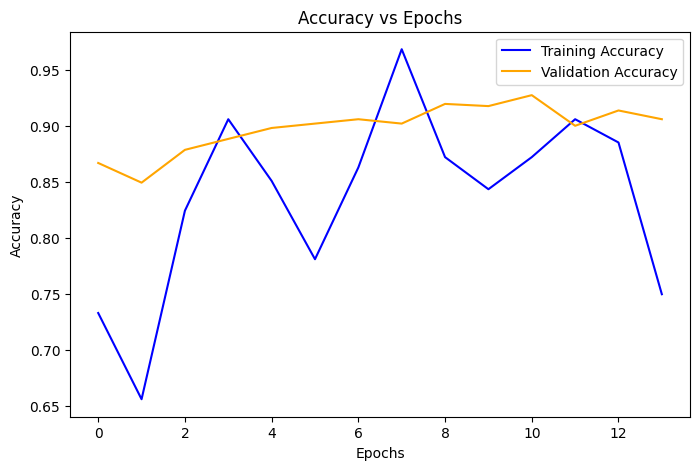

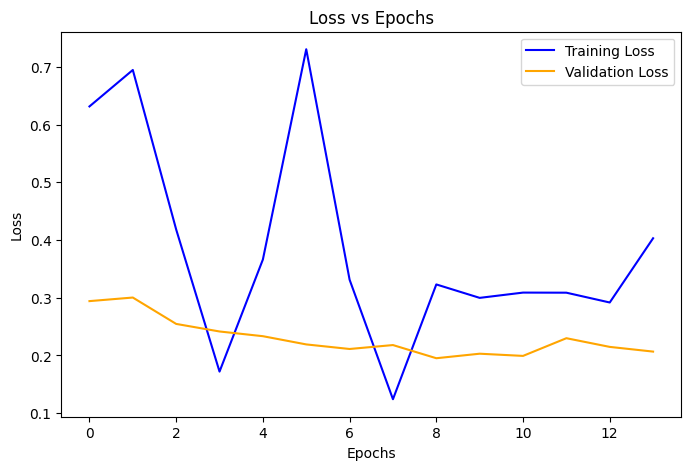

In [10]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h1>unfreezing the last 40 layers

In [11]:
# Unfreeze the last 40 layers of DenseNet121
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Compile with a lower learning rate
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.3,
                              patience=3,
                              min_lr=1e-7,
                              verbose=1)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save the best model automatically
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [15]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=25,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/25
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8692 - loss: 0.3384
Epoch 1: val_loss improved from None to 0.22220, saving model to best_model.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 61s 360ms/step - accuracy: 0.8786 - loss: 0.3264 - val_accuracy: 0.9141 - val_loss: 0.2222 - learning_rate: 1.0000e-05
Epoch 2/25
  1/146 ━━━━━━━━━━━━━━━━━━━━ 45s 313ms/step - accuracy: 0.9375 - loss: 0.2745
Epoch 2: val_loss improved from 0.22220 to 0.21247, saving model to best_model.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9375 - loss: 0.2745 - val_accuracy: 0.9121 - val_loss: 0.2125 - learning_rate: 1.0000e-05
Epoch 3/25
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8875 - loss: 0.2994
Epoch 3: val_loss improved from 0.21247 to 0.20272, saving model to best_model.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 50s 340ms/step - accuracy: 0.8904 - loss: 0.2951 - val_accuracy: 0.9121 - val_loss: 0.2027 - learning_rate: 1.0000e-05
Epoch 4/25
  1/146 ━━━━━━━━━━━━━━━━━━━━ 4

In [16]:
from tensorflow.keras.models import load_model

# Load the best model automatically saved during training
best_model = load_model("best_model.keras")

In [17]:
loss, accuracy = best_model.evaluate(test_generator)
print(f"Final Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {accuracy*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step - accuracy: 0.8830 - loss: 0.2946
Final Test Loss: 0.2946
Final Test Accuracy: 88.30%


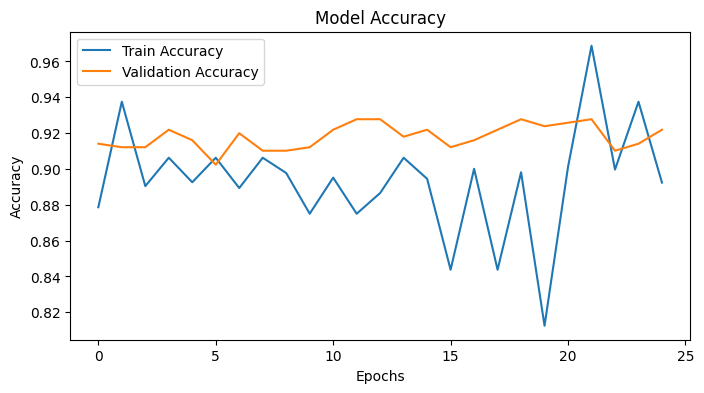

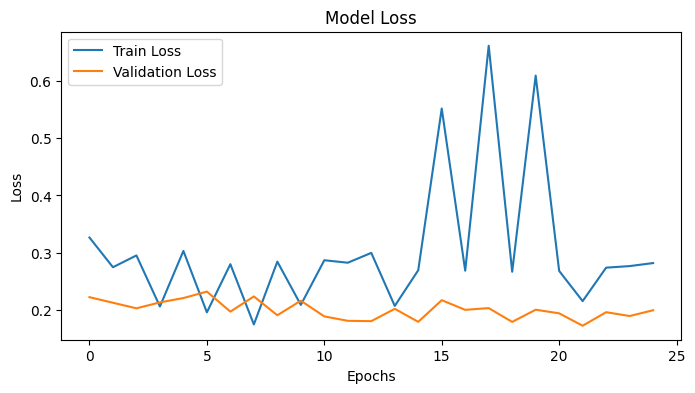

In [18]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()